# 01 — Análisis Exploratorio de Datos (EDA)
**Dataset:** California Housing (CSV original del libro) | **Referencia:** Géron cap. 2 "Look at the Big Picture"

El notebook es solo para exploración visual. El código de producción vive en `src/`.

Corre `make data` antes de abrirlo.

> **Nota:** los datos vienen del CSV de `ageron/data`, no de `fetch_california_housing`.
> Eso significa dos cosas que sklearn oculta: existe la columna categórica
> `ocean_proximity` y hay **207 valores faltantes** en `AveBedrms`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Asegúrate de haber corrido `make data` antes
df = pd.read_parquet('../data/raw/housing.parquet')
print(df.shape)
df.head()

(20640, 10)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,ocean_proximity,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,NEAR BAY,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,NEAR BAY,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,NEAR BAY,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,NEAR BAY,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,NEAR BAY,3.422


## 1. Información general

In [2]:
df.info()
print('\nValores nulos:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MedInc           20640 non-null  float64
 1   HouseAge         20640 non-null  float64
 2   AveRooms         20640 non-null  float64
 3   AveBedrms        20433 non-null  float64
 4   Population       20640 non-null  float64
 5   AveOccup         20640 non-null  float64
 6   Latitude         20640 non-null  float64
 7   Longitude        20640 non-null  float64
 8   ocean_proximity  20640 non-null  object 
 9   MedHouseVal      20640 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

Valores nulos:
MedInc               0
HouseAge             0
AveRooms             0
AveBedrms          207
Population           0
AveOccup             0
Latitude             0
Longitude            0
ocean_proximity      0
MedHouseVal          0
dtype: int64


In [3]:
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.48,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


## 2. Distribución del target (MedHouseVal)

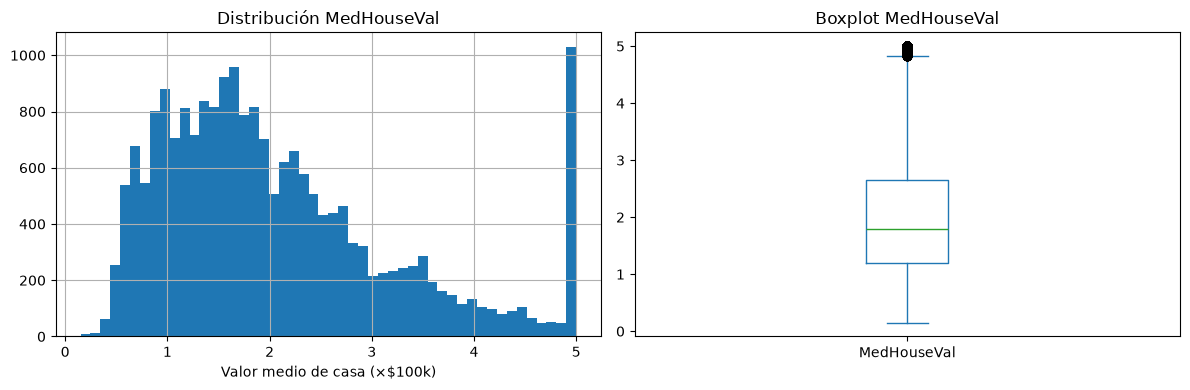

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['MedHouseVal'].hist(bins=50, ax=axes[0])
axes[0].set_title('Distribución MedHouseVal')
axes[0].set_xlabel('Valor medio de casa (×$100k)')

df['MedHouseVal'].plot.box(ax=axes[1])
axes[1].set_title('Boxplot MedHouseVal')
plt.tight_layout()

## 3. Distribución de cada feature

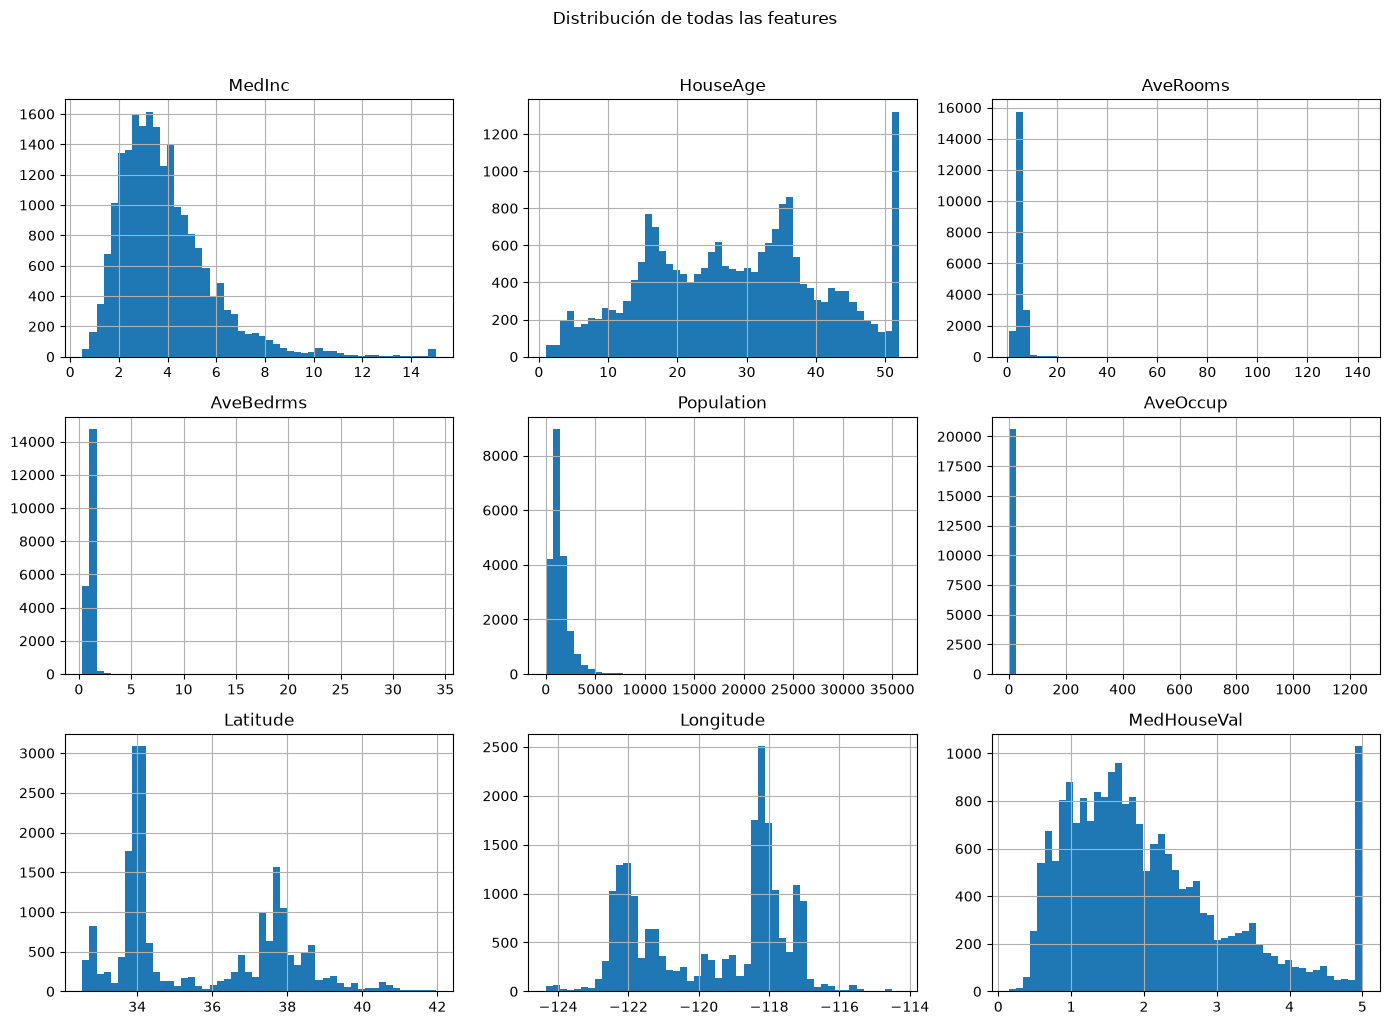

In [5]:
df.hist(bins=50, figsize=(14, 10))
plt.suptitle('Distribución de todas las features', y=1.02)
plt.tight_layout()

## 4. Mapa geográfico (latitud / longitud)

Text(0.5, 1.0, 'California — Precio por zona (tamaño = población)')

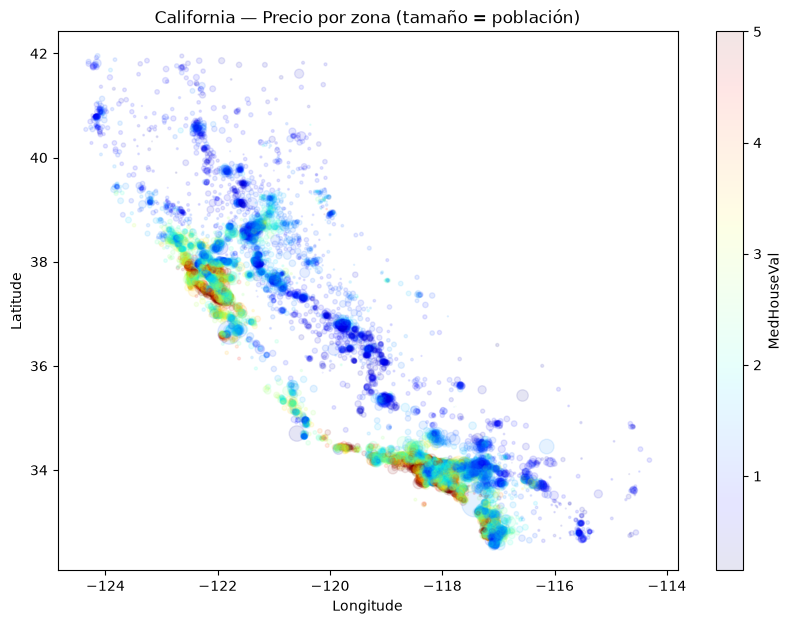

In [6]:
df.plot(
    kind='scatter', x='Longitude', y='Latitude',
    alpha=0.1, figsize=(10, 7),
    c='MedHouseVal', cmap='jet', colorbar=True,
    s=df['Population'] / 100
)
plt.title('California — Precio por zona (tamaño = población)')

## 4b. `ocean_proximity` — la columna que sklearn descarta

Categórica, 5 niveles. Es la única no numérica del dataset, así que necesita
`OneHotEncoder` (ver `src/preprocessing.py`).

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

ISLAND solo tiene 5 filas — ojo con sobreajustarla.


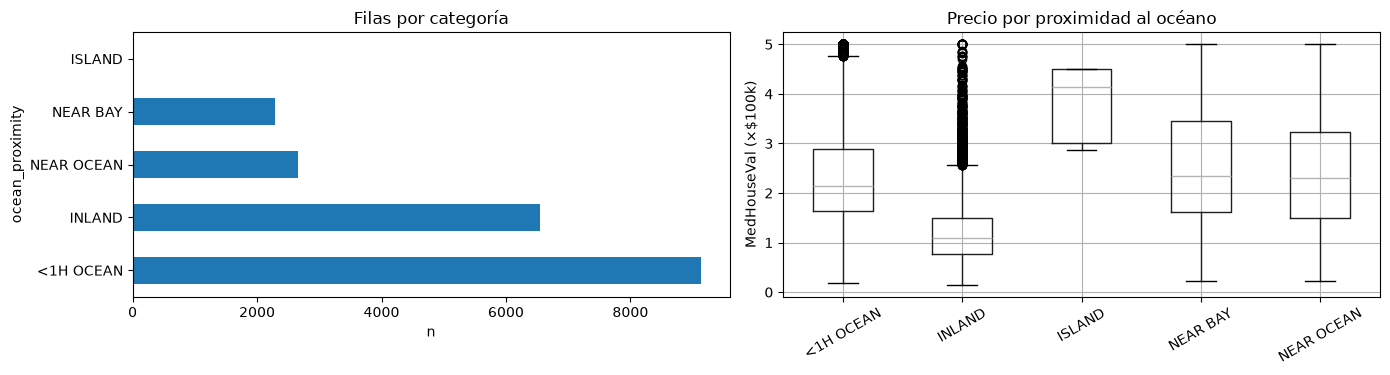

In [7]:
counts = df['ocean_proximity'].value_counts()
print(counts)
print('\nISLAND solo tiene', counts.get('ISLAND', 0), 'filas — ojo con sobreajustarla.')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts.plot.barh(ax=axes[0])
axes[0].set_title('Filas por categoría')
axes[0].set_xlabel('n')

# Precio por categoría: ¿la columna separa de verdad?
df.boxplot(column='MedHouseVal', by='ocean_proximity', ax=axes[1], rot=30)
axes[1].set_title('Precio por proximidad al océano')
axes[1].set_xlabel('')
axes[1].set_ylabel('MedHouseVal (×$100k)')
plt.suptitle('')
plt.tight_layout()

## 4c. Categorías de ingreso — por qué el split va estratificado

`MedInc` es el predictor más fuerte del precio (se ve en la matriz de correlación
de abajo). Si el test set queda con otra mezcla de ingresos que la población real,
el RMSE mide una California que no existe.

`src/features.py` parte `MedInc` en 5 categorías y estratifica el split sobre ellas.

Proporción poblacional:
MedInc
1    0.0398
2    0.3188
3    0.3506
4    0.1763
5    0.1144
Name: proportion, dtype: float64


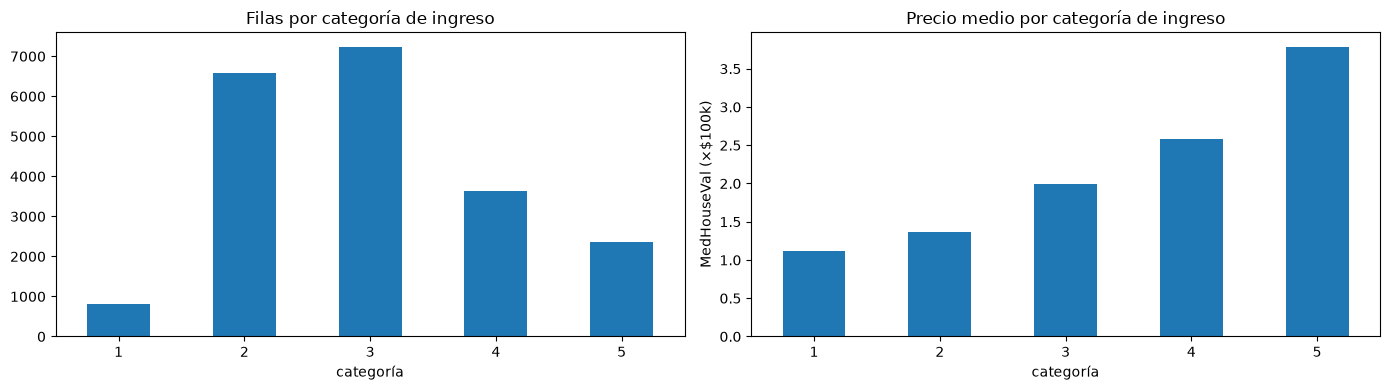

In [8]:
# Mismos cortes que src/features.py
income_cat = pd.cut(df['MedInc'], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

income_cat.value_counts().sort_index().plot.bar(ax=axes[0], rot=0)
axes[0].set_title('Filas por categoría de ingreso')
axes[0].set_xlabel('categoría')

df.groupby(income_cat, observed=True)['MedHouseVal'].mean().plot.bar(ax=axes[1], rot=0)
axes[1].set_title('Precio medio por categoría de ingreso')
axes[1].set_xlabel('categoría')
axes[1].set_ylabel('MedHouseVal (×$100k)')
plt.tight_layout()

print('Proporción poblacional:')
print(income_cat.value_counts(normalize=True).sort_index().round(4))

## 5. Correlaciones


Correlación con MedHouseVal:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046739
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


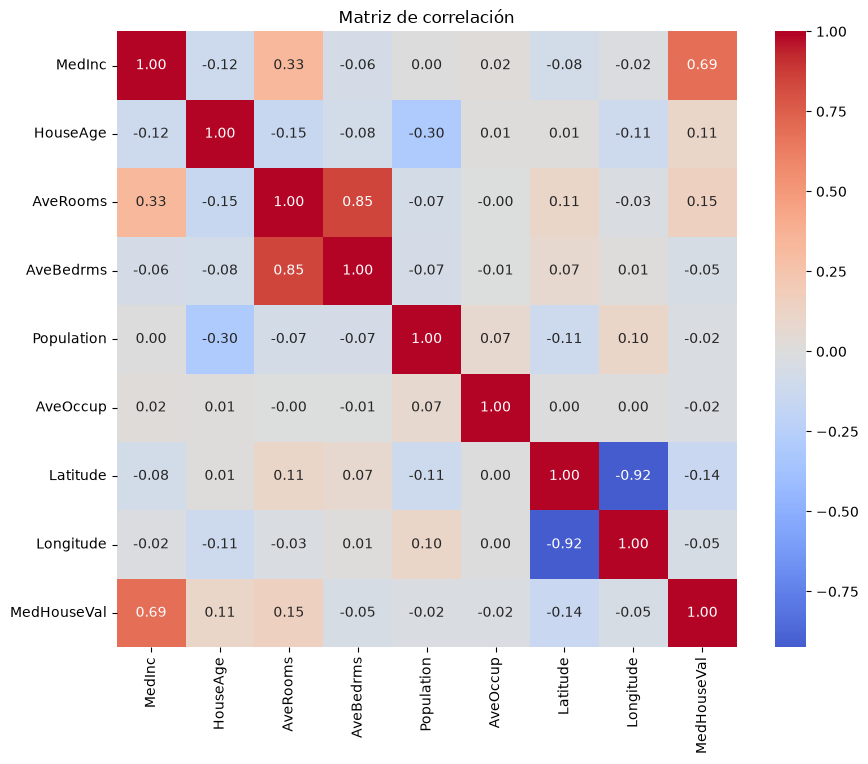

In [9]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
print('\nCorrelación con MedHouseVal:')
print(corr['MedHouseVal'].sort_values(ascending=False))

## 6. Scatter plots de features más correlacionadas
Las features con mayor correlación con el target:

Text(0.5, 1.01, 'Scatter matrix — features vs target')

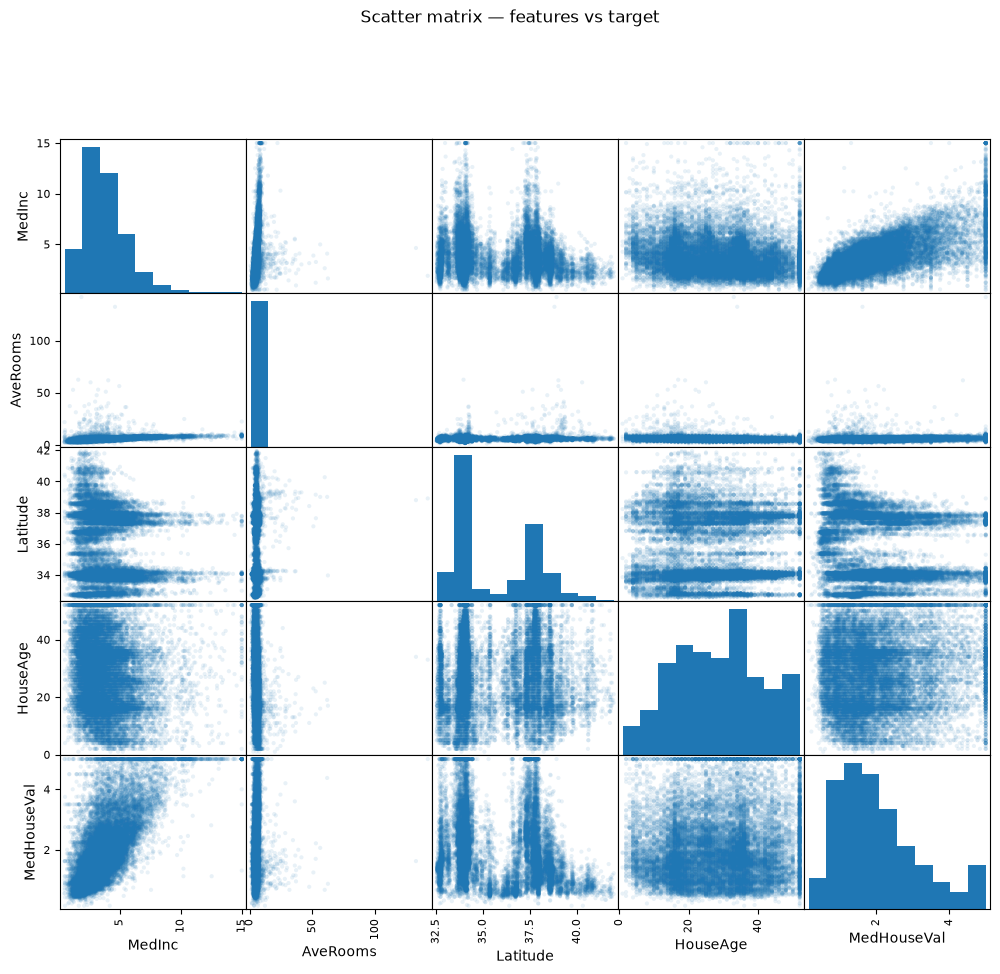

In [10]:
top_features = corr['MedHouseVal'].abs().sort_values(ascending=False).index[1:5]
pd.plotting.scatter_matrix(
    df[list(top_features) + ['MedHouseVal']],
    figsize=(12, 10), alpha=0.1
)
plt.suptitle('Scatter matrix — features vs target', y=1.01)

---
**Siguientes pasos:** Las observaciones de este EDA guían las decisiones en `src/features.py`.
Anota aquí lo que encuentres antes de pasar a `make features`.